#EDA

---



In [1]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
file_path = '/content/drive/MyDrive/SKRIPSI MANTAP/data sosmed/.Process/Merge data/ig_comments.csv'

df = pd.read_csv(file_path)

In [4]:
df.info()
df.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30185 entries, 0 to 30184
Data columns (total 1 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   komen_ig  29908 non-null  object
dtypes: object(1)
memory usage: 235.9+ KB


(30185, 1)

In [5]:
df.head()

,komen_ig
0,🔥🔥🔥🔥 Alhamdulillah
1,🔥😂🔥
2,gassskannnn 🔥🔥🔥
3,"Nah ini baru mantap.,semangat rakyatku 🇮🇩💪🤲"
4,Next deddy Sitorus


##Analisis Missing Values

In [6]:
missing = df.isnull().sum()

missing_df = pd.DataFrame({
    'Jumlah Missing': missing.values,
    'Persentase (%)': (missing.values / len(df)) * 100
})

print(missing_df)

   Jumlah Missing  Persentase (%)
0             277        0.917674


##Analisis Duplicate Data

In [7]:
duplicate_count = df['komen_ig'].duplicated().sum()

print(f"Jumlah data duplikat: {duplicate_count}")


duplicates = df[df.duplicated()]
print(duplicates[['komen_ig']])

Jumlah data duplikat: 4009
                                          komen_ig
15                              🔥🔥🔥🔥 Alhamdulillah
16                                             🔥😂🔥
17                                 gassskannnn 🔥🔥🔥
18     Nah ini baru mantap.,semangat rakyatku 🇮🇩💪🤲
19                              Next deddy Sitorus
...                                            ...
30126                                          👏👏👏
30129            Dalam hati yang paling kecilnya,.
30160                                            Y
30164                                        Amien
30171                                            🙏

[4009 rows x 1 columns]


##Analisis Noise

In [8]:
# Pastikan data string
df.columns = df.columns.str.strip()

print(df.columns)

Index(['komen_ig'], dtype='object')


Deteksi URL

In [9]:
import re

url_pattern = r'http\S+|www\S+'

df['contains_url'] = df['komen_ig'].apply(
    lambda x: bool(re.search(url_pattern, str(x)))
)

print(df['contains_url'].value_counts())

print(df[df['contains_url']]['komen_ig'].head())

contains_url
False    30164
True        21
Name: count, dtype: int64
1116                      Ini halall ayo habiskan brewww😂😂
6448     Da real melawan tenryubitto  awakwakwakwakwakk...
6580                                       Wadaaawwwww🔥🔥🔥🔥
7148     https://www.instagram.com/reel/DN_Fw6rDoTG?com...
10030    Teruntuk teman2 semoga bisa saling menjaga sat...
Name: komen_ig, dtype: object


Deteksi Hashtag

In [10]:
hashtag_pattern = r'#\w+'

df['contains_hashtag'] = df['komen_ig'].apply(
    lambda x: bool(re.search(hashtag_pattern, str(x)))
)

print(df['contains_hashtag'].value_counts())

print(df[df['contains_hashtag']]['komen_ig'])

contains_hashtag
False    30185
Name: count, dtype: int64
Series([], Name: komen_ig, dtype: object)


Deteksi Mention

In [11]:
mention_pattern = r'@\w+'

df['contains_mention'] = df['komen_ig'].apply(
    lambda x: bool(re.search(mention_pattern, str(x)))
    if pd.notnull(x) else False
)

print(df['contains_mention'].value_counts())

df[df['contains_mention']]

contains_mention
False    30175
True        10
Name: count, dtype: int64


,komen_ig,contains_url,contains_hashtag,contains_mention
3143,AZAB ALLAH.. ngatain RAKYAT INDONESIA TOLOL.. ...,False,False,True
3530,Nah loh @@agusprakoso8 ini baru bnr,False,False,True
3787,Ketat ketir si @@king_uyakuya sama Eko😂😂😂,False,False,True
11290,NEXT RUMAH @ketua_dprri,False,False,True
16204,Halaa@aalllll,False,False,True
17884,TINDAKAN MEREKA SALAH😢😢TAPI SAYA SANGAT SANGAT...,False,False,True
21330,kenapa kesel@ya krn di batasi POLISI TNI 😂 ko...,False,False,True
23906,Polisi wajib bertindak tegas krn sdh bukan lg ...,False,False,True
27209,"Bu, ayo kembali ke jalan yg benar @@smindrawat...",False,False,True
28979,Semoga #@king_uyakuya MB #@astridkuya makin b...,False,False,True


Deteksi Emoji

In [12]:
emoji_pattern = re.compile(
    "["
    u"\U0001F600-\U0001F64F"  # emoticon
    u"\U0001F300-\U0001F5FF"  # simbol & pictograph
    u"\U0001F680-\U0001F6FF"  # transport
    u"\U0001F1E0-\U0001F1FF"  # flags
    "]+",
    flags=re.UNICODE
)

df['contains_emoji'] = df['komen_ig'].apply(
    lambda x: bool(emoji_pattern.search(str(x)))
)

print(df['contains_emoji'].value_counts())

print(df[df['contains_emoji']]['komen_ig'])

contains_emoji
False    18065
True     12120
Name: count, dtype: int64
0                                  🔥🔥🔥🔥 Alhamdulillah
1                                                 🔥😂🔥
2                                     gassskannnn 🔥🔥🔥
3         Nah ini baru mantap.,semangat rakyatku 🇮🇩💪🤲
5        Serem yaa kalau masa sudah tak terkendali 😢,
                             ...                     
30153                                        Aamiin 😁
30167                                       Aamiin 🤲🏻
30171                                               🙏
30174              Main lapor polisi,polisi di💸gercep
30176                  Orang duit dari rakyat kok.. 😂
Name: komen_ig, Length: 12120, dtype: object


Deteksi Simbol Berlebih

In [13]:
symbol_pattern = r'[^\w\s]'

df['contains_symbol'] = df['komen_ig'].apply(
    lambda x: bool(re.search(symbol_pattern, str(x)))
)

print(df['contains_symbol'].value_counts())

print(df[df['contains_symbol']]['komen_ig'].head())

contains_symbol
True     21770
False     8415
Name: count, dtype: int64
0                              🔥🔥🔥🔥 Alhamdulillah
1                                             🔥😂🔥
2                                 gassskannnn 🔥🔥🔥
3     Nah ini baru mantap.,semangat rakyatku 🇮🇩💪🤲
5    Serem yaa kalau masa sudah tak terkendali 😢,
Name: komen_ig, dtype: object


Deteksi Karakter Berulang
*   baguusssss
*   mantapppp



In [14]:
repeat_pattern = r'(.)\1{4,}'

df['contains_repeated_char'] = df['komen_ig'].apply(
    lambda x: bool(re.search(repeat_pattern, str(x).lower()))
)

print(df['contains_repeated_char'].value_counts())

print(df[df['contains_repeated_char']]['komen_ig'].head())


contains_repeated_char
False    28460
True      1725
Name: count, dtype: int64
40                   MMMAAANNTTTAAAPPP  LLLAAAAAAAHHHHH
45    Anarkis yaaaaa, semoga ini bisa dijadikn pelaj...
58    ╭━━━┳╮╱╭┳━━━┳━━━╮┃╭━╮┃┃╱┃┃╭━╮┃╭━╮┃┃╰━╯┃┃╱┃┃┃╱┃...
74               Giliran hartanya di jarah rakyat......
86    Nah kek gini ni kan adil sila ke 5 nya ada.......
Name: komen_ig, dtype: object


Deteksi Teks Irrelevant
*   terlalu pendek
*   hanya angka/simbol



In [15]:
def irrelevant_text(text):

    text = str(text).strip()

    # terlalu pendek
    if len(text) < 3:
        return True

    # hanya angka/simbol
    if re.fullmatch(r'[\W\d_]+', text):
        return True

    return False

df['irrelevant_text'] = df['komen_ig'].apply(irrelevant_text)

print(df['irrelevant_text'].value_counts())

print(df[df['irrelevant_text']]['komen_ig'])

irrelevant_text
False    27874
True      2311
Name: count, dtype: int64
1                                                      🔥😂🔥
16                                                     🔥😂🔥
53                                                      😭😭
55                                                      👏🔥
58       ╭━━━┳╮╱╭┳━━━┳━━━╮┃╭━╮┃┃╱┃┃╭━╮┃╭━╮┃┃╰━╯┃┃╱┃┃┃╱┃...
                               ...                        
30092                                                  😢😢😢
30111                                                   😂😂
30126                                                  👏👏👏
30160                                                    Y
30171                                                    🙏
Name: komen_ig, Length: 2311, dtype: object


Ringkasan Noise


===== RINGKASAN NOISE =====
          Jenis Noise  Jumlah
0          URL/Tautan      21
1             Hashtag       0
2             Mention      10
3   Karakter Berulang    1725
4  Teks Tidak Relevan    2311


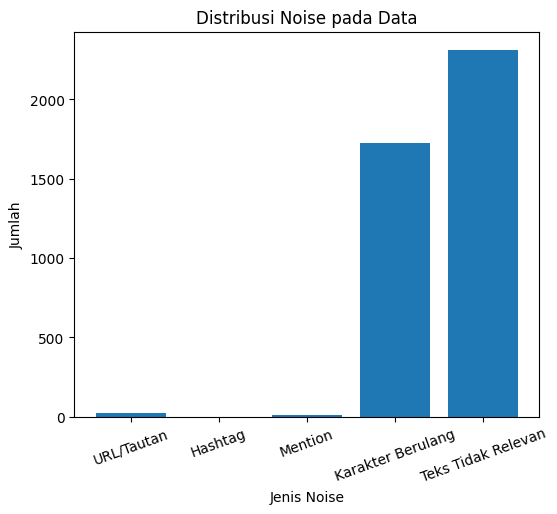

In [16]:
noise_summary = {
    'URL/Tautan': df['contains_url'].sum(),
    'Hashtag': df['contains_hashtag'].sum(),
    'Mention': df['contains_mention'].sum(),
    #'Emoji': df['contains_emoji'].sum(),
    #'Simbol': df['contains_symbol'].sum(),
    'Karakter Berulang': df['contains_repeated_char'].sum(),
    'Teks Tidak Relevan': df['irrelevant_text'].sum()
}

noise_df = pd.DataFrame(
    noise_summary.items(),
    columns=['Jenis Noise', 'Jumlah']
)

print("\n===== RINGKASAN NOISE =====")
print(noise_df)

# Visualisasi Noise
plt.figure(figsize=(6,5))
plt.bar(noise_df['Jenis Noise'], noise_df['Jumlah'])
plt.title('Distribusi Noise pada Data')
plt.xlabel('Jenis Noise')
plt.ylabel('Jumlah')
plt.xticks(rotation=20)
plt.show()

#PREPROCESSING

---



In [17]:
#copy dataset, agar data asli tidak berubah
clean_df = df.copy()

##Case Folding

In [18]:
clean_df['clean_text'] = clean_df['komen_ig'].str.lower()
print(clean_df[['clean_text']].head())

                                    clean_text
0                           🔥🔥🔥🔥 alhamdulillah
1                                          🔥😂🔥
2                              gassskannnn 🔥🔥🔥
3  nah ini baru mantap.,semangat rakyatku 🇮🇩💪🤲
4                           next deddy sitorus


##Noise Removal

In [19]:
import re

def clean_noise(text):

    text = str(text)

    #hapus url
    text = re.sub(r'http\S+|www\S+', '', text)

    #hapus hashtag
    text = re.sub(r'#', '', text)

    #hapus mention
    text = re.sub(r'@', '', text)

    #hapus spasi berlebih
    text = re.sub(r'\s+', ' ', text).strip()

    return text

clean_df['clean_text'] = clean_df['clean_text'].apply(clean_noise)

##Normalisasi

In [20]:
def normalize_repeated_char(word):

    word = re.sub(r'(.)\1{2,}', r'\1', word)

    return word


def normalize_text(text):

    words = text.split()

    normalized_words = [
        normalize_repeated_char(word)
        for word in words
    ]

    return ' '.join(normalized_words)

clean_df['clean_text'] = clean_df['clean_text'].apply(normalize_text)
print(clean_df[['clean_text']].head())

                                    clean_text
0                              🔥 alhamdulillah
1                                          🔥😂🔥
2                                     gaskan 🔥
3  nah ini baru mantap.,semangat rakyatku 🇮🇩💪🤲
4                           next deddy sitorus


##Cleaning Data

Hapus Teks tidak Relevan

In [21]:
def irrelevant_text(text):

    # Tangani missing value terlebih dahulu
    if pd.isna(text):
        return False      # biarkan NaN, akan dihapus pada langkah terakhir

    text = str(text).strip()

    # Terlalu pendek
    if len(text) < 3:
        return True

    # Hanya simbol atau angka
    if re.fullmatch(r'[\W\d_]+', text):
        return True

    return False

clean_df = clean_df[
    ~clean_df['clean_text'].apply(irrelevant_text)
]

print("Jumlah data setelah hapus text irrelevant:")
print(len(clean_df))

Jumlah data setelah hapus text irrelevant:
27865


Hapus Duplikat Data

In [22]:
clean_df = clean_df.drop_duplicates(subset=['clean_text'])

print("\nJumlah data setelah hapus duplikat:")
print(len(clean_df))


Jumlah data setelah hapus duplikat:
25094


Hapus Missing Value

In [23]:
clean_df = clean_df.dropna(subset=['clean_text'])

print("Jumlah data setelah hapus missing value:")
print(len(clean_df))

Jumlah data setelah hapus missing value:
25094


Ubah Karakter Berulang

#HASIL

In [24]:
print("\n===== HASIL PREPROCESSING =====")

print(clean_df[['komen_ig', 'clean_text']].head(10))

print("\nJumlah data akhir:")
print(len(clean_df))


===== HASIL PREPROCESSING =====
                                             komen_ig  \
0                                  🔥🔥🔥🔥 Alhamdulillah   
2                                     gassskannnn 🔥🔥🔥   
3         Nah ini baru mantap.,semangat rakyatku 🇮🇩💪🤲   
4                                  Next deddy Sitorus   
5        Serem yaa kalau masa sudah tak terkendali 😢,   
6                                      MASUK PA EKO 😂   
7      Ya Allah semoga besok ga ada darurat militer 😢   
8      Apakah praktek simulasi RUU perampasan aset? 😮   
9                                           Ini diaaa   
10  Pelajaran yang hebat untuk orang-orang yang so...   

                                           clean_text  
0                                     🔥 alhamdulillah  
2                                            gaskan 🔥  
3         nah ini baru mantap.,semangat rakyatku 🇮🇩💪🤲  
4                                  next deddy sitorus  
5        serem yaa kalau masa sudah tak terkendali 😢,  
6  

#SIMPAN HASIL

In [25]:
import os

final_df = clean_df[['clean_text']].copy()

# ubah nama kolom
final_df.columns = ['ig_clean']

In [26]:
folder_path = '/content/drive/MyDrive/SKRIPSI MANTAP/data sosmed/.Process/Clean data'

os.makedirs(folder_path, exist_ok=True)

Simpan ke gdrive

In [27]:
output_path = f'{folder_path}/ig_clean.csv'

final_df.to_csv(output_path, index=False)

print("File berhasil disimpan di:")
print(output_path)

File berhasil disimpan di:
/content/drive/MyDrive/SKRIPSI MANTAP/data sosmed/.Process/Clean data/ig_clean.csv


Download

In [28]:
from google.colab import files

files.download(output_path)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

#DISTRIBUSI JUMLAH KATA TIAP KOMENTAR

---



In [29]:
# ======================================
# Distribusi Panjang Komentar
# ======================================

# Hitung jumlah kata pada setiap komentar
clean_df['word_count'] = clean_df['clean_text'].apply(
    lambda x: len(str(x).split())
)

# Hitung jumlah komentar pada setiap rentang
less_50 = (clean_df['word_count'] < 50).sum()
between_50_99 = ((clean_df['word_count'] >= 50) & (clean_df['word_count'] < 100)).sum()
between_100_199 = ((clean_df['word_count'] >= 100) & (clean_df['word_count'] < 200)).sum()
more_equal_200 = (clean_df['word_count'] >= 200).sum()

total = len(clean_df)

print("Distribusi Panjang Komentar")
print("="*40)
print(f"< 50 kata      : {less_50} komentar ({less_50/total*100:.2f}%)")
print(f"50-99 kata     : {between_50_99} komentar ({between_50_99/total*100:.2f}%)")
print(f"100-199 kata   : {between_100_199} komentar ({between_100_199/total*100:.2f}%)")
print(f"≥ 200 kata     : {more_equal_200} komentar ({more_equal_200/total*100:.2f}%)")

Distribusi Panjang Komentar
< 50 kata      : 24808 komentar (98.86%)
50-99 kata     : 236 komentar (0.94%)
100-199 kata   : 43 komentar (0.17%)
≥ 200 kata     : 7 komentar (0.03%)
